In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

# Load the dataset
crime = pd.read_csv("CrimeData.csv")

print("Raw data preview:")
print(crime.iloc[:6, :5].to_string(index=False))

Raw data preview:
 Unnamed: 0     DR_NO              Date Rptd               DATE OCC  TIME OCC
          1 201516622 10/21/2020 12:00:00 AM 10/18/2020 12:00:00 AM      1845
          7 201115217 10/29/2020 12:00:00 AM 07/07/2020 12:00:00 AM      1400
         10 240605846 02/06/2024 12:00:00 AM 06/20/2020 12:00:00 AM         1
         16 201820230 11/08/2020 12:00:00 AM 11/08/2020 12:00:00 AM       730
         17 201707577 03/20/2020 12:00:00 AM 03/20/2020 12:00:00 AM      1320
         19 201405023 01/19/2020 12:00:00 AM 01/19/2020 12:00:00 AM      1850


In [10]:
# Convert date columns to datetime
crime["DATE OCC"]  = pd.to_datetime(crime["DATE OCC"],  format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
crime["Date Rptd"] = pd.to_datetime(crime["Date Rptd"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
 
# Sort by DATE OCC, TIME OCC, Date Rptd ascending (oldest first)
crime = crime.sort_values(["DATE OCC", "TIME OCC", "Date Rptd"]).reset_index(drop=True)
 
print("\nSorted data preview:")
print(crime.iloc[:6, :5].to_string(index=False))
 
# Aggregate crimes by date 
crime["Date_Clean"] = crime["DATE OCC"].dt.date
 
daily_crimes = (
    crime.groupby("Date_Clean")
    .size()
    .reset_index(name="Count")
)
daily_crimes["Date_Clean"] = pd.to_datetime(daily_crimes["Date_Clean"])
 
print("\nDaily crime counts (first 6 rows):")
print(daily_crimes.head(6).to_string(index=False))
print(daily_crimes.head())


Sorted data preview:
 Unnamed: 0     DR_NO  Date Rptd   DATE OCC  TIME OCC
     108260 201104035 2020-01-01 2020-01-01         1
     179818 200904042 2020-01-02 2020-01-01         1
      43050 201804446 2020-01-09 2020-01-01         1
      52347 202006047 2020-02-12 2020-01-01         1
      91687 200505805 2020-02-12 2020-01-01         1
     121045 200707858 2020-03-27 2020-01-01         1

Daily crime counts (first 6 rows):
Date_Clean  Count
2020-01-01    512
2020-01-02    184
2020-01-03    196
2020-01-04    222
2020-01-05    187
2020-01-06    203
  Date_Clean  Count
0 2020-01-01    512
1 2020-01-02    184
2 2020-01-03    196
3 2020-01-04    222
4 2020-01-05    187


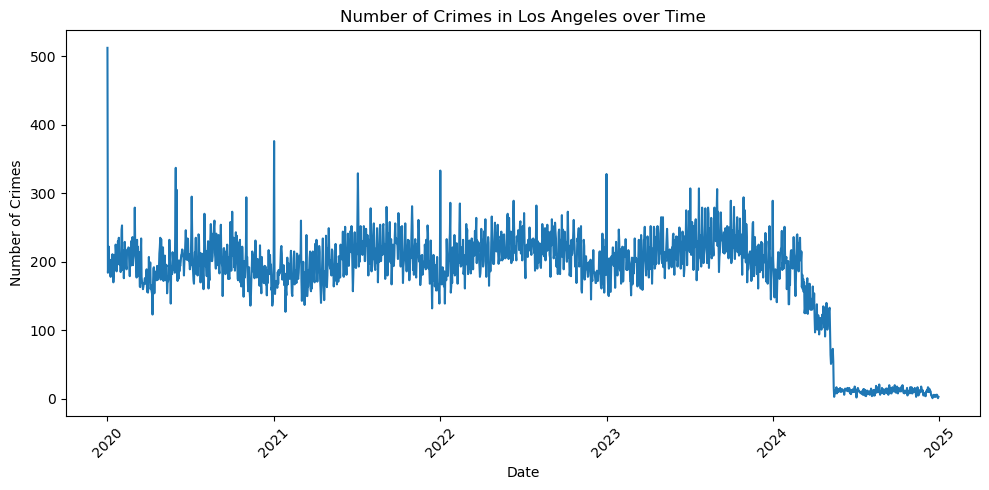

In [11]:
# Time series plot
plt.figure(figsize=(10, 5))
plt.plot(daily_crimes["Date_Clean"], daily_crimes["Count"])
plt.title("Number of Crimes in Los Angeles over Time")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

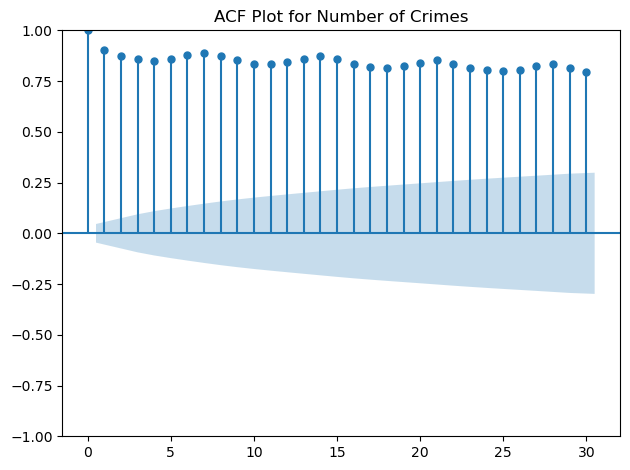

In [12]:
# ACF plot
plt.figure(figsize=(8, 4))
plot_acf(daily_crimes["Count"], lags=30)
plt.title("ACF Plot for Number of Crimes")
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

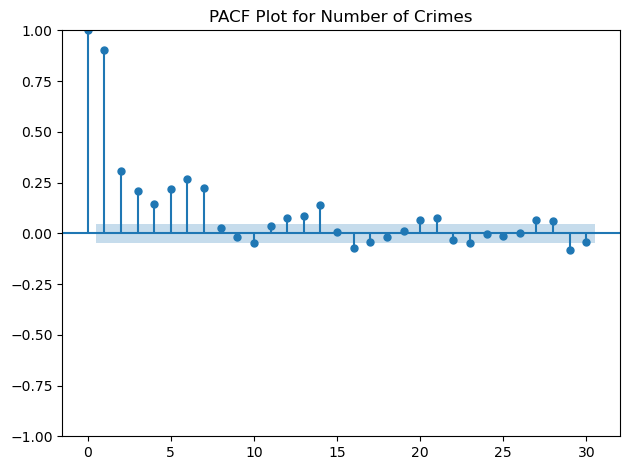

In [13]:
# PACF plot
plt.figure(figsize=(8, 4))
plot_pacf(daily_crimes["Count"], lags=30, method="ywm")
plt.title("PACF Plot for Number of Crimes")
plt.tight_layout()
plt.show()